<a href="https://colab.research.google.com/github/bforoura/ML26/blob/main/Module4_Regression/environmental_trends.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Training Models - Regression and Classification with Climate Data**


**Source**: https://www.kaggle.com/datasets/adilshamim8/temperature

<br>

* In this notebook, we utilize the World Surface Temperature and Emissions Trends Dataset, a multi-variable climate dataset designed to explore real-world environmental patterns.

* The dataset consists of global observations capturing socio-economic and ecological factors affecting climate change.

* The goal of this exercise is to apply the core concepts covered in Chapter 4 — ranging from **Closed-Form Linear Regression** and **Gradient Descent** to **Polynomial Features**, **Regularization**, and **Logistic/Softmax Classification** — using a scientific dataset.


---

**Key Features**:
  * Year: The recording year of the observation.
  * Country: The geographic region or nation.
  * Average Temperature (°C): The annual average surface temperature.
  * CO2 Emissions (Metric Tons per Capita): Greenhouse gas output per person.* * Sea Level Rise (mm): Annual coastal sea-level increase.
  * Rainfall (mm): Total annual precipitation.
  * Population: Total national population.
  * Renewable Energy (%): Percentage of energy generated from sustainable sources.
  * Extreme Weather Events: Annual count of recorded natural disasters.
  * Forest Area (%): Percentage of land covered by forests.

---
**Target**

* The primary target variable depends on whether we are framing the problem around **regression** or **classification**:

  * **Regression**: The target variable is typically **Average Temperature (°C)** or **Sea Level Rise (mm)**, where we predict continuous numerical values based on features like carbon emissions, renewable energy adoption, and forest area.

  * **Classification Tasks (Chapter 4)**: The target variable can be transformed into a discrete category, such as a **binary climate risk indicator** (e.g., High vs. Low risk) or multi-class risk tiers.



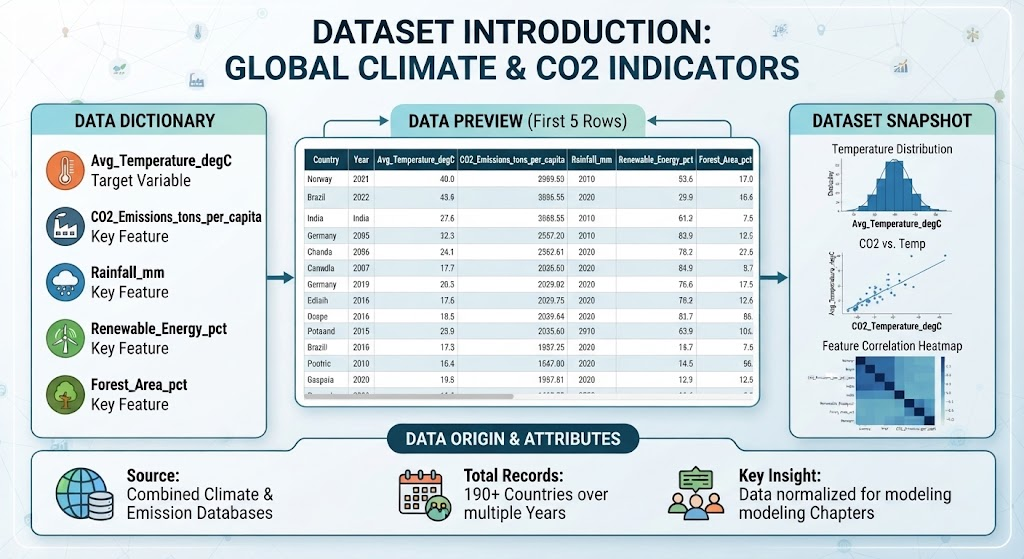

# **Setup and Data Loading**

* Let's load the dataset (update_temperature.csv) into a DataFrame and inspect its structure, data types, and summary statistics to ensure everything loaded correctly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset from the local file path
file_path = 'update_temperature.csv'
df = pd.read_csv(file_path)

# Display the first few rows of the dataset
print("Dataset Head:")
print(df.head())

# Display dataset info including data types and non-null counts
print("\nDataset Info:")
print(df.info())

# Display summary statistics for numerical features
print("\nSummary Statistics:")
print(df.describe())

Dataset Head:
   Year        Country  Avg_Temperature_degC  CO2_Emissions_tons_per_capita  \
0  2000  United States                  13.5                           20.2   
1  2000          China                  12.8                            2.7   
2  2000        Germany                   9.3                           10.1   
3  2000         Brazil                  24.9                            1.9   
4  2000      Australia                  21.7                           17.2   

   Sea_Level_Rise_mm  Rainfall_mm  Population  Renewable_Energy_pct  \
0                  0          715   282500000                   6.2   
1                  0          645  1267000000                  16.5   
2                  0          700    82200000                   6.6   
3                  0         1760   175000000                  83.7   
4                  0          534    19200000                   8.8   

   Extreme_Weather_Events  Forest_Area_pct  
0                      38             3

# **Feature Scaling**

* Let's see why feature scaling is critical for machine learning models.

* Notice how the dataset features span vastly different numerical ranges—for instance, Population scales up to the billions, while CO2_Emissions_tons_per_capita and Avg_Temperature_degC are in single or double digits.

* If we use **Gradient Descent** or **regularized models** without scaling, features with larger numerical magnitudes will dominate the cost function.


* We **must** use scikit-learn's **StandardScaler** to standardize our features so they have a **mean of zero and a standard deviation of one**.


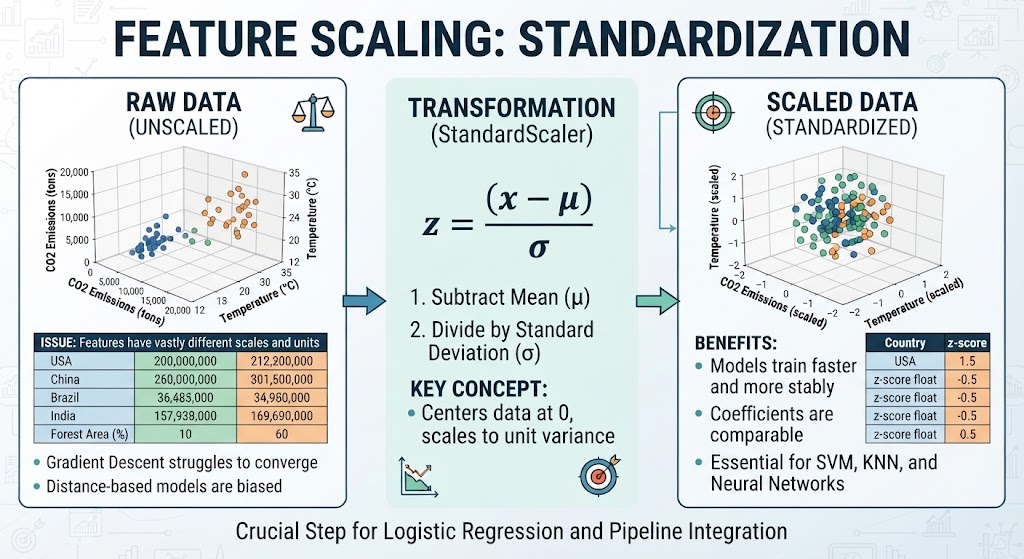

In [2]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Load the dataset
df = pd.read_csv('update_temperature.csv')

# Select multiple features for multi-variable regression / scaling demonstration
feature_cols = ['CO2_Emissions_tons_per_capita', 'Rainfall_mm', 'Population', 'Renewable_Energy_pct']
X = df[feature_cols].values
y = df['Avg_Temperature_degC'].values

# Display unscaled feature statistics
print("Unscaled Feature Means (should be far from 0):")
print(X.mean(axis=0))
print("\nUnscaled Feature Standard Deviations (should not be 1):")
print(X.std(axis=0))

# Initialize and fit the StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Display scaled feature statistics
print("\nScaled Feature Means (should be ~0):")
print(X_scaled.mean(axis=0).round(5))
print("\nScaled Feature Standard Deviations (should be 1):")
print(X_scaled.std(axis=0).round(5))

Unscaled Feature Means (should be far from 0):
[7.67371795e+00 9.37397436e+02 2.95207512e+08 3.12038462e+01]

Unscaled Feature Standard Deviations (should not be 1):
[5.43270146e+00 5.31243868e+02 4.40061345e+08 2.66559944e+01]

Scaled Feature Means (should be ~0):
[-0. -0.  0. -0.]

Scaled Feature Standard Deviations (should be 1):
[1. 1. 1. 1.]


# **Gradient Descent Optimization**


* Here, we explore **Gradient Descent optimization** to train our regression model iteratively.

* Because our features **(CO2_Emissions_tons_per_capita and Population)** span vastly different scales, raw features can cause Gradient Descent to oscillate wildly or fail to converge.

* To ensure stability and efficient convergence, we combine **feature scaling (StandardScaler)** and **Stochastic Gradient Descent (SGDRegressor)** into a scikit-learn Pipeline.

* We then fit the pipeline on our data and examine the optimized model coefficients.

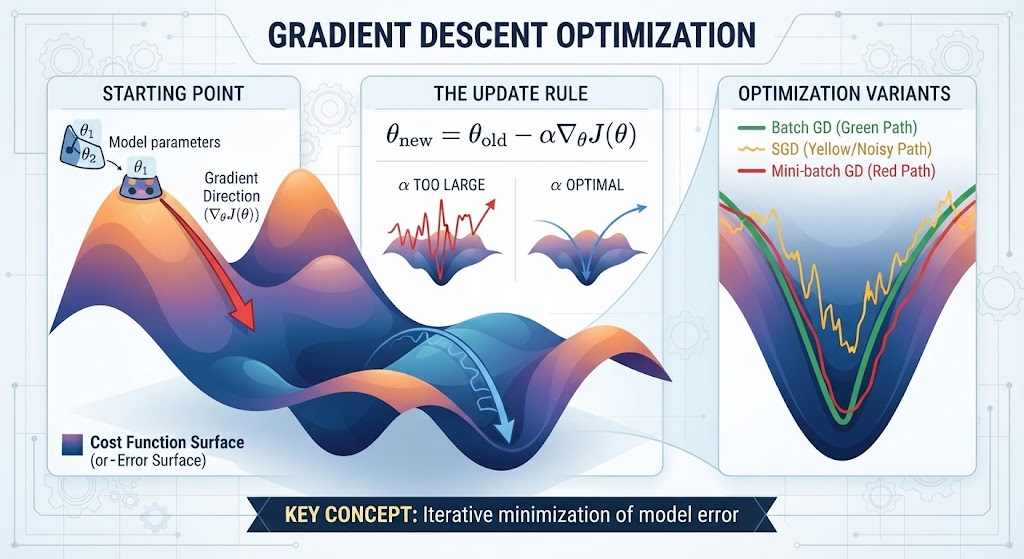

In [3]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor

# Load the dataset
df = pd.read_csv('update_temperature.csv')

# Define features and target variable
feature_cols = ['CO2_Emissions_tons_per_capita', 'Rainfall_mm', 'Population', 'Renewable_Energy_pct']
X = df[feature_cols]
y = df['Avg_Temperature_degC']

# Create a machine learning pipeline chaining StandardScaler and SGDRegressor
# max_iter and tol control convergence parameters
sgd_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', SGDRegressor(max_iter=1000, tol=1e-3, learning_rate='invscaling', eta0=0.01, random_state=42))
])

# Fit the pipeline to the training data
sgd_pipeline.fit(X, y)

# Extract and display the trained coefficients from the pipeline's regressor step
trained_regressor = sgd_pipeline.named_steps['regressor']
print("SGD Pipeline Intercept:")
print(trained_regressor.intercept_)

print("\nSGD Pipeline Coefficients:")
for feature, coef in zip(feature_cols, trained_regressor.coef_):
    print(f"{feature}: {coef:.4f}")

SGD Pipeline Intercept:
[17.60854518]

SGD Pipeline Coefficients:
CO2_Emissions_tons_per_capita: -1.1666
Rainfall_mm: 1.3548
Population: 0.7316
Renewable_Energy_pct: 1.6644


# **Explanation of SGDRegressor Parameters**


* **max_iter=1000**: Sets the maximum number of passes over the training data (epochs) allowed for the optimization algorithm to converge.

* **tol=1e-3**: The stopping criterion will stop operations when the loss stops improving by at least tol over consecutive epochs.

* **learning_rate='invscaling'** : Specifies that the learning rate decreases gradually at each time step $t$ using an inverse scaling schedule, helping the model settle closer to the global minimum.

* **eta0=0.01**: The initial learning rate (step size) used at the beginning of training before inverse scaling takes effect.

* **random_state=42**: A seed for the pseudo-random number generator to ensure reproducibility across different runs.

# **Pipeline Visualization**


* Let's use scikit-learn's built-in set_config(display="diagram") feature.

*  This renders an interactive, visual HTML diagram of our machine learning pipeline (sgd_pipeline), displaying each processing step (StandardScaler and SGDRegressor) and its configuration parameters.



In [4]:
from sklearn import set_config

# Enable HTML pipeline representation for Jupyter / Google Colab
set_config(display="diagram")

# Display the pipeline diagram
sgd_pipeline

Pipeline(steps=[('scaler', StandardScaler()),
                ('regressor', SGDRegressor(random_state=42))])

# **Visualizing SGDRegressor Predictions and Error Analysis**


* We now now need to erform an error analysis and visualization of the model we trained using our sgd_pipeline.

* Specifically, we generate predictions on our training set using the pipeline, and compute key regression error metrics:
   * Mean Squared Error (MSE)
   * Root Mean Squared Error (RMSE)
   * Coefficient of Determination ($R^2$)
   
* Then we will plot a scatter plot comparing actual versus predicted values alongside a perfect-fit reference line to evaluate how well the model learned.

SGDRegressor Evaluation Metrics:
Mean Squared Error (MSE): 38.9975
Root Mean Squared Error (RMSE): 6.2448
R-squared (R2): 0.2474


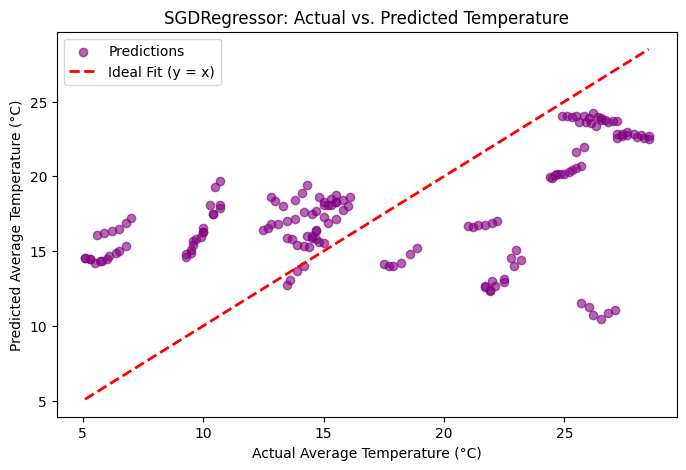

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv('update_temperature.csv')

# Define features and target variable used in the SGD pipeline
feature_cols = ['CO2_Emissions_tons_per_capita', 'Rainfall_mm', 'Population', 'Renewable_Energy_pct']
X = df[feature_cols]
y = df['Avg_Temperature_degC']

# Generate predictions using our previously fitted sgd_pipeline
y_pred = sgd_pipeline.predict(X)

# Compute error metrics
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print("SGDRegressor Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# Visualize Actual vs Predicted Values
plt.figure(figsize=(8, 5))
plt.scatter(y, y_pred, color='purple', alpha=0.6, label='Predictions')

# Plot perfect prediction reference line (y = x)
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Fit (y = x)')

plt.xlabel('Actual Average Temperature (°C)')
plt.ylabel('Predicted Average Temperature (°C)')
plt.title('SGDRegressor: Actual vs. Predicted Temperature')
plt.legend()
plt.show()

# **Interpretation of the Actual vs. Predicted Plot**


* The above scatter plot evaluates how well the SGDRegressor pipeline's predictions match the actual values from the dataset.


* The Red Dashed Line ($y = x$) represents the line of ideal fit.

* If the model made 100% accurate predictions, every purple dot would lie directly on this red line.

* Each purple dots represents a sample from the dataset, mapped by its **Actual Temperature (horizontal axis)** versus the model's **Predicted Temperature (vertical axis)**.


* The data points form distinct groups or clusters rather than a random scatter.

* This is  because the dataset contains multi-country and multi-year records where certain nations share similar environmental profiles.

* Notice how many points deviate significantly from the red line.
  * For instance, when the actual temperature is around 5°C to 7°C, the model overpredicts, guessing values around 15°C.
  * Conversely, when actual temperatures reach 26°C, some points are severely underpredicted down near 10°C.
  
* This divergences indicate that a **simple linear model struggles to capture the complex, non-linear relationships** between these environmental features and temperature.

* Therefore, we need **polynomial features** or **more advanced modeling techniques**.

# **Polynomial Regression**


* Let's move beyond simple linear relationships to model non-linear patterns in the climate dataset.

* As we saw in our previous error analysis, environmental phenomena rarely follow strict straight lines.


* We use scikit-learn's **PolynomialFeatures** to generate **quadratic interaction** terms ($x_1^2, x_2^2, x_1 x_2$, etc.) and chain it together with **LinearRegression** inside a Pipeline.

* Also, note that you need to experiment with both types of scaling and report if any differences where detected.

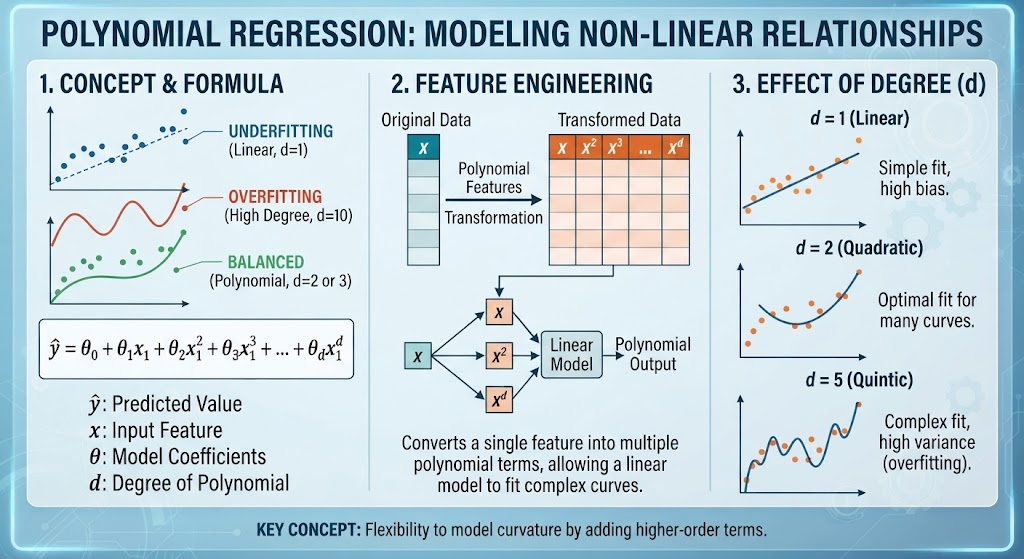

In [6]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression

# Load the dataset
df = pd.read_csv('update_temperature.csv')

# Define features and target variable
feature_cols = ['CO2_Emissions_tons_per_capita', 'Rainfall_mm']
X = df[feature_cols]
y = df['Avg_Temperature_degC']

# Create a polynomial regression pipeline
# degree=2 adds squared terms and interaction terms
poly_pipeline = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# Fit the pipeline to the data
poly_pipeline.fit(X, y)

# Retrieve coefficients and intercept
trained_regressor = poly_pipeline.named_steps['regressor']
poly_transformer = poly_pipeline.named_steps['poly_features']

print("Polynomial Regression Intercept:")
print(f"{trained_regressor.intercept_:.4f}")

print("\nPolynomial Feature Coefficients:")
feature_names = poly_transformer.get_feature_names_out(feature_cols)
for name, coef in zip(feature_names, trained_regressor.coef_):
    print(f"{name}: {coef:.4f}")

Polynomial Regression Intercept:
17.6205

Polynomial Feature Coefficients:
CO2_Emissions_tons_per_capita: -13.3771
Rainfall_mm: 2.4247
CO2_Emissions_tons_per_capita^2: 13.6408
CO2_Emissions_tons_per_capita Rainfall_mm: -2.4127
Rainfall_mm^2: -0.1007


# **Polynomial Regression Error Analysis and Visualization**


* Let's perform error analysis and do visualization for our polynomial regression model, similar to the evaluation we did for our linear model.

* We compute key performance metrics—Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the Coefficient of Determination ($R^2$)—to quantify how well the quadratic and interaction features capture the non-linear dynamics of our climate dataset compared to the simple linear model.

* We also plot an Actual vs. Predicted scatter plot with an ideal reference line ($y = x$).

Polynomial Regression Evaluation Metrics:
Mean Squared Error (MSE): 17.6202
Root Mean Squared Error (RMSE): 4.1976
R-squared (R2): 0.6600


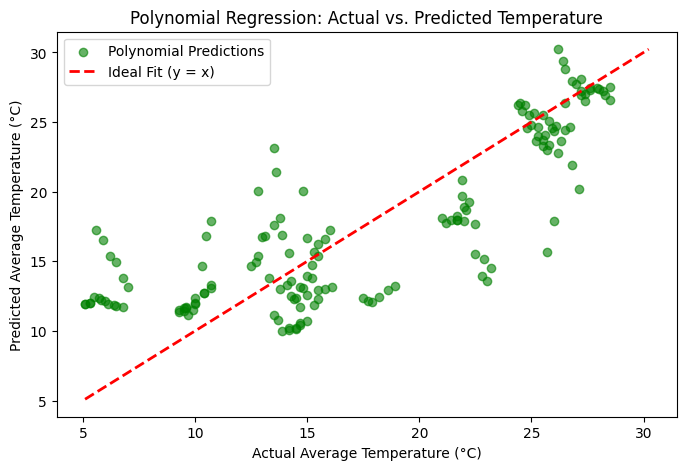

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Generate predictions using our previously fitted poly_pipeline
y_pred = poly_pipeline.predict(X)

# Compute error metrics
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print("Polynomial Regression Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# Visualize Actual vs Predicted Values
plt.figure(figsize=(8, 5))
plt.scatter(y, y_pred, color='green', alpha=0.6, label='Polynomial Predictions')

# Plot perfect prediction reference line (y = x)
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Fit (y = x)')

plt.xlabel('Actual Average Temperature (°C)')
plt.ylabel('Predicted Average Temperature (°C)')
plt.title('Polynomial Regression: Actual vs. Predicted Temperature')
plt.legend()
plt.show()

# **Upgrading Polynomial Regression with Higher Degrees and Additional Features**


* To achieve a satisfactory fit and overcome the limitations of our previous two-feature quadratic model, we expand our pipeline in two powerful ways:

  * **Adding More Features**: incorporate a richer set of predictors from our dataset (CO2_Emissions_tons_per_capita, Rainfall_mm, Renewable_Energy_pct, and Forest_Area_pct).

  * **Increasing Polynomial Complexity**:  increase the polynomial degree (e.g., to degree 3) to capture complex, non-linear interactions across these environmental indicators.


Upgraded Polynomial Regression Metrics:
Mean Squared Error (MSE): 0.1029
Root Mean Squared Error (RMSE): 0.3208
R-squared (R2): 0.9980


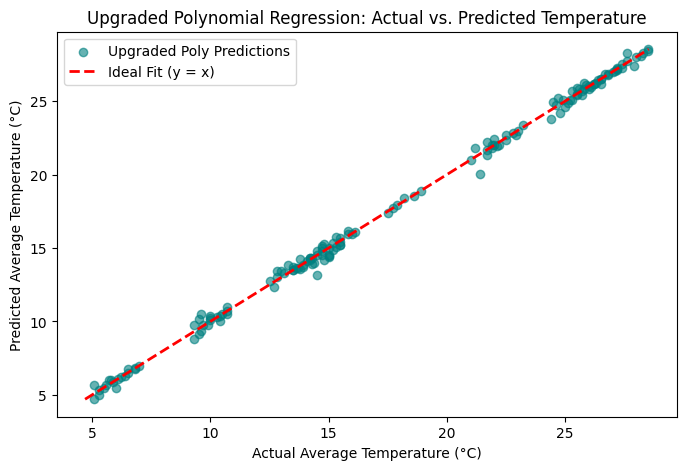

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv('update_temperature.csv')

# Expand feature selection to capture richer climate dynamics
feature_cols = ['CO2_Emissions_tons_per_capita', 'Rainfall_mm', 'Renewable_Energy_pct', 'Forest_Area_pct']
X = df[feature_cols]
y = df['Avg_Temperature_degC']

# Create an upgraded polynomial regression pipeline
poly_pipeline_upgraded = Pipeline([
    ('poly_features', PolynomialFeatures(degree=5, include_bias=False)),
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# Fit the pipeline to the data
poly_pipeline_upgraded.fit(X, y)

# Generate predictions and evaluate
y_pred_upgraded = poly_pipeline_upgraded.predict(X)
mse = mean_squared_error(y, y_pred_upgraded)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred_upgraded)

print("Upgraded Polynomial Regression Metrics:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# Visualize Actual vs Predicted Values for the Upgraded Model
plt.figure(figsize=(8, 5))
plt.scatter(y, y_pred_upgraded, color='teal', alpha=0.6, label='Upgraded Poly Predictions')

# Plot perfect prediction reference line (y = x)
min_val = min(y.min(), y_pred_upgraded.min())
max_val = max(y.max(), y_pred_upgraded.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Fit (y = x)')

plt.xlabel('Actual Average Temperature (°C)')
plt.ylabel('Predicted Average Temperature (°C)')
plt.title('Upgraded Polynomial Regression: Actual vs. Predicted Temperature')
plt.legend()
plt.show()

# **Progression of Model Complexity**

* The degree 5 model output looks tight and accurate.

* The data points hug the red ideal-fit line ($y = x$) with an $R^2$ of approximately 0.9980 and an RMSE of just 0.32°C, showing that increasing the polynomial complexity and expanding our feature set successfully captured the non-linear relationships in the climate dataset.


* **ML workflows** traditionally progress step-by-step—starting with simple linear models on a single feature before expanding to multi-feature and high-degree polynomial models.

* This progressive approach allows us to:
  *  visualize relationships in lower dimensions before moving to abstract multi-variable spaces.

  * see firsthand why **simple models underfit** complex real-world phenomena like climate trends.
  
  * Understand the direct need for model capacity adjustments, feature engineering, and **regularization** (e.g. Ridge and Lasso regression).


# **Regularized Linear Models (Ridge and Lasso)**


* Here, we explore **Regularized Linear Models**.

* When we trained our degree 5 polynomial model earlier, we saw how high complexity can fit the data closely.

* However, **high-degree polynomials are also extremely prone to overfitting** when exposed to unseen validation or **test data**.

* To prevent this, **regularization adds a penalty to the loss function** based on the size of the model's coefficients:

* **Ridge Regression ($L_2$ Regularization)**:
   * Adds a penalty equal to the square of the magnitude of coefficients ($\alpha \sum \theta_j^2$), shrinking weights toward zero without eliminating them completely.

* **Lasso Regression ($L_1$ Regularization)**:

  * Adds a penalty equal to the absolute value of the magnitude of coefficients ($\alpha \sum \vert{}\theta_j\vert{}$), which can drive less important feature weights down to exactly zero, performing **automatic feature selection**.

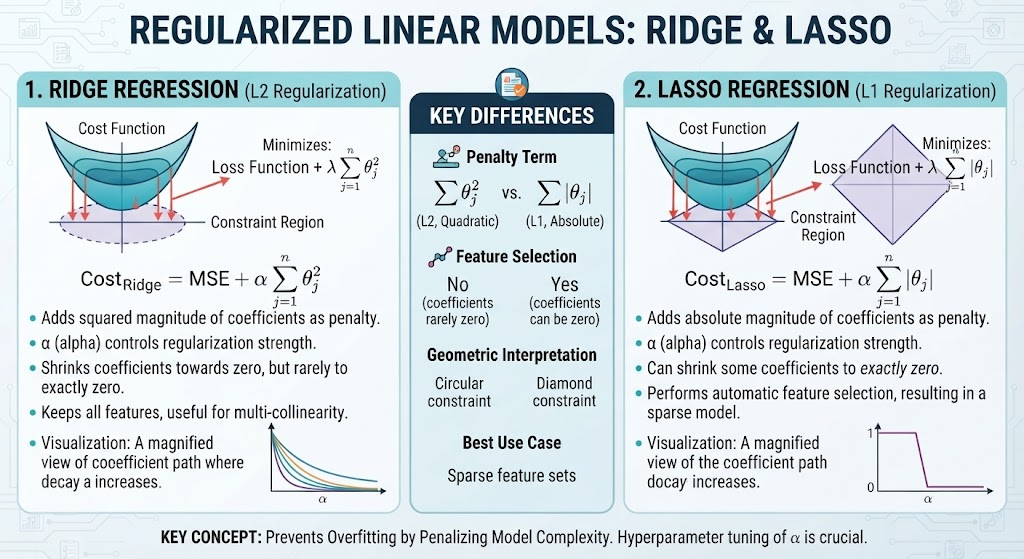

Ridge Regression (L2) Metrics:
RMSE: 1.5902 | R2: 0.9512

Lasso Regression (L1) Metrics:
RMSE: 2.3885 | R2: 0.8899


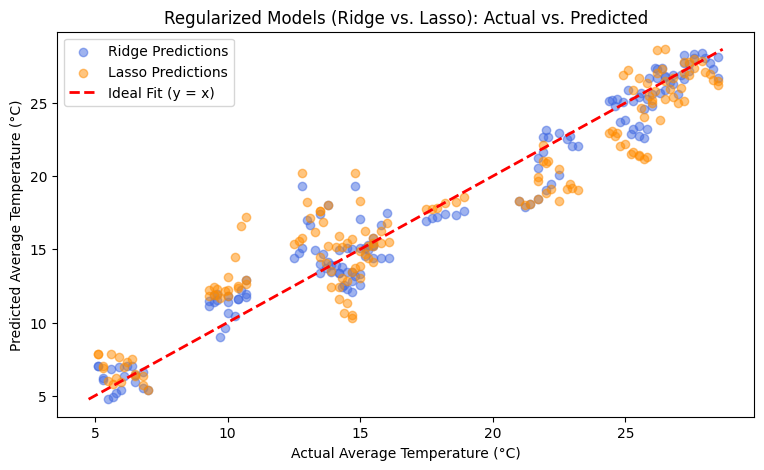

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv('update_temperature.csv')

# Define features and target variable
feature_cols = ['CO2_Emissions_tons_per_capita', 'Rainfall_mm', 'Renewable_Energy_pct', 'Forest_Area_pct']
X = df[feature_cols]
y = df['Avg_Temperature_degC']

# Create Ridge Regression Pipeline (L2 Regularization)
ridge_pipeline = Pipeline([
    ('poly_features', PolynomialFeatures(degree=5, include_bias=False)),
    ('scaler', StandardScaler()),
    ('regressor', Ridge(alpha=1.0, random_state=42))
])

# Create Lasso Regression Pipeline (L1 Regularization)
lasso_pipeline = Pipeline([
    ('poly_features', PolynomialFeatures(degree=5, include_bias=False)),
    ('scaler', StandardScaler()),
    ('regressor', Lasso(alpha=0.1, max_iter=5000, random_state=42))
])

# Fit both pipelines
ridge_pipeline.fit(X, y)
lasso_pipeline.fit(X, y)

# Generate predictions
y_pred_ridge = ridge_pipeline.predict(X)
y_pred_lasso = lasso_pipeline.predict(X)

# Evaluate Ridge
ridge_rmse = np.sqrt(mean_squared_error(y, y_pred_ridge))
ridge_r2 = r2_score(y, y_pred_ridge)

# Evaluate Lasso
lasso_rmse = np.sqrt(mean_squared_error(y, y_pred_lasso))
lasso_r2 = r2_score(y, y_pred_lasso)

print("Ridge Regression (L2) Metrics:")
print(f"RMSE: {ridge_rmse:.4f} | R2: {ridge_r2:.4f}")

print("\nLasso Regression (L1) Metrics:")
print(f"RMSE: {lasso_rmse:.4f} | R2: {lasso_r2:.4f}")

# Visualize regularized predictions vs Actual
plt.figure(figsize=(9, 5))
plt.scatter(y, y_pred_ridge, color='royalblue', alpha=0.5, label='Ridge Predictions')
plt.scatter(y, y_pred_lasso, color='darkorange', alpha=0.5, label='Lasso Predictions')

min_val = min(y.min(), y_pred_ridge.min(), y_pred_lasso.min())
max_val = max(y.max(), y_pred_ridge.max(), y_pred_lasso.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Fit (y = x)')

plt.xlabel('Actual Average Temperature (°C)')
plt.ylabel('Predicted Average Temperature (°C)')
plt.title('Regularized Models (Ridge vs. Lasso): Actual vs. Predicted')
plt.legend()
plt.show()

# **A Note on Regularization**


* This is a crucial point.
*  It is completely normal to feel puzzled when they see advanced regularization techniques like **Ridge and Lasso actually perform "worse"** (in terms of in-sample training error and $R^2$) than an unregularized, high-degree model.

* To clear up this confusion, we need to emphasize the following situations:


* **Training Fit vs. Generalization**:
  * Unregularized models can achieve near-perfect training scores by memorizing noise and fluctuations in the training set.
  * **Regularization** intentionally trades away some training accuracy (**introducing bias**) to ensure the model generalizes safely to unseen test data.
  
  
* **The Danger of Overfitting**:
  * While degree 5 unregularized polynomial regression looked amazing on our training dataset, it is often a ticking time bomb for validation or **test sets** where new data points are introduced.
  
 * **Choosing $\alpha$ (Alpha)**:
   * Regularization strength is governed by the hyperparameter $\alpha$.
   * If $\alpha$ is set too high, the model becomes overly penalized, resulting in underfitting (as seen with Lasso here).
   
   * Tuning $\alpha$ via cross-validation is key to striking the right balance

# **Experimenting with Alpha Hyperparameters in Ridge and Lasso**


* To see how sensitive our regularized models are to the penalty strength, we will run an experiment across different values of $\alpha$ (e.g., $0.001, 0.01, 0.1, 1.0, 10, 100$).

* This allows use to observe how a very small $\alpha$ behaves almost like an unregularized model, while a very large $\alpha$ over-penalizes the coefficients and leads to underfitting.

In [13]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv('update_temperature.csv')
feature_cols = ['CO2_Emissions_tons_per_capita', 'Rainfall_mm', 'Renewable_Energy_pct', 'Forest_Area_pct']
X = df[feature_cols]
y = df['Avg_Temperature_degC']

# Define a range of alpha values to test
alpha_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

print("--- Ridge Regression Alpha Experiment ---")
for a in alpha_values:
    ridge_exp = Pipeline([
        ('poly_features', PolynomialFeatures(degree=5, include_bias=False)),
        ('scaler', StandardScaler()),
        ('regressor', Ridge(alpha=a, random_state=42))
    ])
    ridge_exp.fit(X, y)
    y_pred = ridge_exp.predict(X)
    print(f"Alpha: {a:6.3f} | RMSE: {np.sqrt(mean_squared_error(y, y_pred)):.4f} | R2: {r2_score(y, y_pred):.4f}")

print("\n--- Lasso Regression Alpha Experiment ---")
for a in alpha_values:
    lasso_exp = Pipeline([
        ('poly_features', PolynomialFeatures(degree=5, include_bias=False)),
        ('scaler', StandardScaler()),
        ('regressor', Lasso(alpha=a, max_iter=5000, random_state=42))
    ])
    lasso_exp.fit(X, y)
    y_pred = lasso_exp.predict(X)
    print(f"Alpha: {a:6.3f} | RMSE: {np.sqrt(mean_squared_error(y, y_pred)):.4f} | R2: {r2_score(y, y_pred):.4f}")

--- Ridge Regression Alpha Experiment ---
Alpha:  0.001 | RMSE: 0.8764 | R2: 0.9852
Alpha:  0.010 | RMSE: 0.9798 | R2: 0.9815
Alpha:  0.100 | RMSE: 1.2064 | R2: 0.9719
Alpha:  1.000 | RMSE: 1.5902 | R2: 0.9512
Alpha: 10.000 | RMSE: 2.2618 | R2: 0.9013
Alpha: 100.000 | RMSE: 3.2885 | R2: 0.7913

--- Lasso Regression Alpha Experiment ---
Alpha:  0.001 | RMSE: 1.0901 | R2: 0.9771
Alpha:  0.010 | RMSE: 1.5196 | R2: 0.9554
Alpha:  0.100 | RMSE: 2.3885 | R2: 0.8899
Alpha:  1.000 | RMSE: 4.3156 | R2: 0.6406
Alpha: 10.000 | RMSE: 7.1985 | R2: 0.0000
Alpha: 100.000 | RMSE: 7.1985 | R2: 0.0000


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.250e+01, tolerance: 8.084e-01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.401e+00, tolerance: 8.084e-01
  model = cd_fast.enet_coordinate_descent(


# **Visualizing the Effect of Alpha Hyperparameters**


* To make the impact of regularization strength intuitive, let's write a self-contained code cell that loops through various alpha values, calculates the RMSE for both Ridge and Lasso regression pipelines, and generates a logarithmic plot comparing their performance trends.

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.250e+01, tolerance: 8.084e-01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.401e+00, tolerance: 8.084e-01
  model = cd_fast.enet_coordinate_descent(


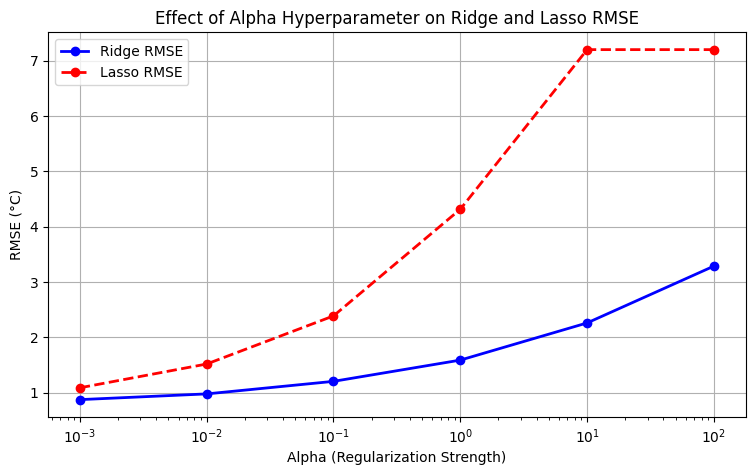

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error

# Load the dataset
df = pd.read_csv('update_temperature.csv')
feature_cols = ['CO2_Emissions_tons_per_capita', 'Rainfall_mm', 'Renewable_Energy_pct', 'Forest_Area_pct']
X = df[feature_cols]
y = df['Avg_Temperature_degC']

# Define a range of alpha values to test
alpha_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

ridge_rmses = []
lasso_rmses = []

# Evaluate Ridge and Lasso across alpha values
for a in alpha_values:
    ridge_exp = Pipeline([
        ('poly_features', PolynomialFeatures(degree=5, include_bias=False)),
        ('scaler', StandardScaler()),
        ('regressor', Ridge(alpha=a, random_state=42))
    ])
    ridge_exp.fit(X, y)
    ridge_rmses.append(np.sqrt(mean_squared_error(y, ridge_exp.predict(X))))

    lasso_exp = Pipeline([
        ('poly_features', PolynomialFeatures(degree=5, include_bias=False)),
        ('scaler', StandardScaler()),
        ('regressor', Lasso(alpha=a, max_iter=5000, random_state=42))
    ])
    lasso_exp.fit(X, y)
    lasso_rmses.append(np.sqrt(mean_squared_error(y, lasso_exp.predict(X))))

# Plotting the alpha effects
plt.figure(figsize=(9, 5))
plt.plot(alpha_values, ridge_rmses, 'bo-', linewidth=2, label='Ridge RMSE')
plt.plot(alpha_values, lasso_rmses, 'ro--', linewidth=2, label='Lasso RMSE')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('RMSE (°C)')
plt.title('Effect of Alpha Hyperparameter on Ridge and Lasso RMSE')
plt.legend()
plt.grid(True)
plt.show()

# **Graph of Alpha Hyperparameter Effects**

* The plot above visualizes how increasing the regularization strength ($\alpha$) impacts the Root Mean Squared Error (RMSE) for both Ridge and Lasso regression models:

  * **Low Alpha ($\alpha = 0.001$)**: Both models yield low RMSE values, performing similarly to an unregularized model because the penalty is too weak to constrain the polynomial coefficients.
  
  * **Moderate Alpha ($0.1$ to $1.0$)**: As alpha increases, the error begins to rise. Ridge (blue line) increases smoothly and maintains strong predictive stability, whereas Lasso (red dashed line) climbs much faster due to feature elimination.
  
  * **High Alpha ($\alpha = 10.0$ and $100.0$)**: **Lasso** completely plateaus at a high RMSE ($7.1985$), which corresponds to an $R^2$ of zero where all coefficients are driven to zero. **Ridge** scales up more gracefully but also suffers from underfitting at high penalty values.

# **Logistic Regression for Binary Classification**


* Having explored regression models for predicting continuous numerical values (like temperature), we now transition to Logistic Regression, one of the fundamental algorithms for binary classification.

* Unlike linear regression, which outputs continuous values, logistic regression estimates the probability that a given instance belongs to a specific category (e.g., whether a region experiences high or low carbon emissions).

* We use the sigmoid function to map predicted values to a probability between 0 and 1, and chain our preprocessing steps into a scikit-learn Pipeline.

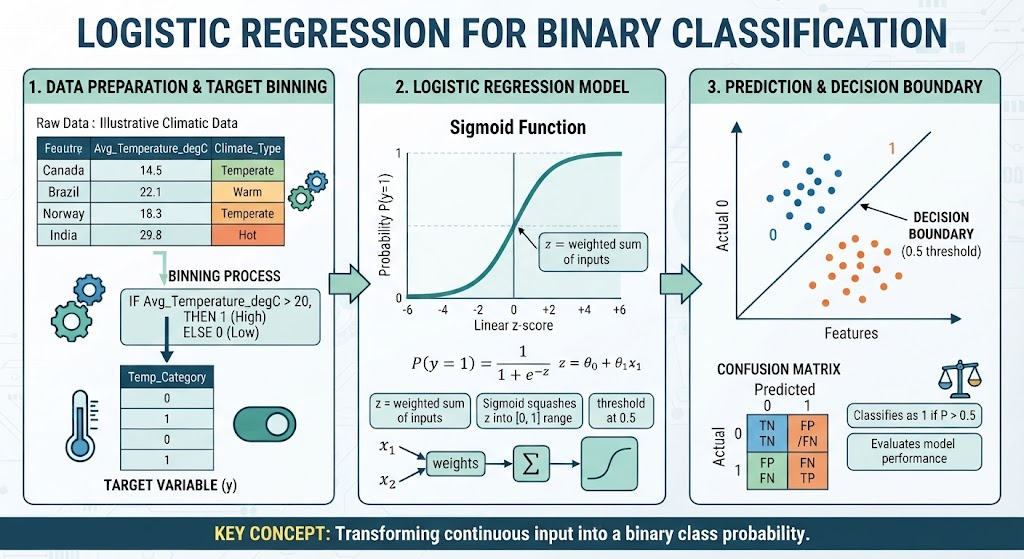

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the dataset
df = pd.read_csv('update_temperature.csv')

# Create a binary target variable for classification:
# 1 if Average Temperature is above the median, 0 otherwise
median_temp = df['Avg_Temperature_degC'].median()
df['High_Temp_Class'] = (df['Avg_Temperature_degC'] > median_temp).astype(int)

# Define features and binary target
feature_cols = ['CO2_Emissions_tons_per_capita', 'Rainfall_mm', 'Renewable_Energy_pct', 'Forest_Area_pct']
X = df[feature_cols]
y = df['High_Temp_Class']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create Logistic Regression Pipeline
log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42))
])

# Fit the pipeline to the training data
log_reg_pipeline.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = log_reg_pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Test Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Logistic Regression Test Accuracy: 0.7500

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.72      0.76        18
           1       0.69      0.79      0.73        14

    accuracy                           0.75        32
   macro avg       0.75      0.75      0.75        32
weighted avg       0.76      0.75      0.75        32

Confusion Matrix:
[[13  5]
 [ 3 11]]


# **Classification Evaluation (Confusion Matrix and ROC Curve)**


** To evaluate our logistic regression classifier beyond simple accuracy, we generate a Confusion Matrix Heatmap and an ROC (Receiver Operating Characteristic) Curve with AUC.

* These tools allow us to inspect true positives, false positives, sensitivity, and specificity across classification thresholds.

Accuracy: 0.7500

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.72      0.76        18
           1       0.69      0.79      0.73        14

    accuracy                           0.75        32
   macro avg       0.75      0.75      0.75        32
weighted avg       0.76      0.75      0.75        32



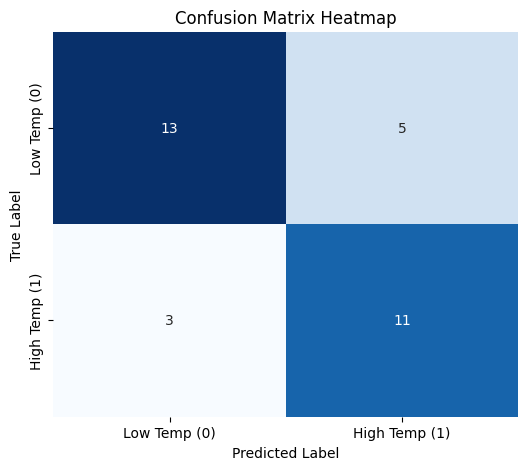

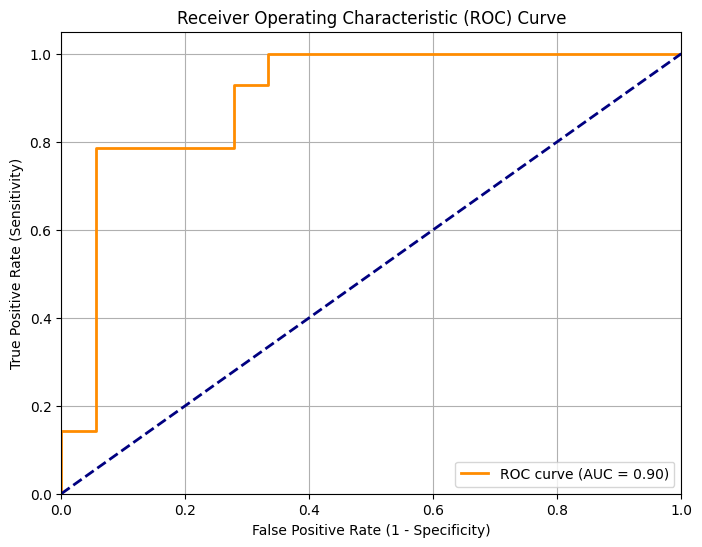

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score

# Load the dataset
df = pd.read_csv('update_temperature.csv')

# Create binary target variable for classification
median_temp = df['Avg_Temperature_degC'].median()
df['High_Temp_Class'] = (df['Avg_Temperature_degC'] > median_temp).astype(int)

# Define features and binary target
feature_cols = ['CO2_Emissions_tons_per_capita', 'Rainfall_mm', 'Renewable_Energy_pct', 'Forest_Area_pct']
X = df[feature_cols]
y = df['High_Temp_Class']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and fit Logistic Regression Pipeline
log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42))
])
log_reg_pipeline.fit(X_train, y_train)

# Predictions and probabilities
y_pred = log_reg_pipeline.predict(X_test)
y_pred_proba = log_reg_pipeline.predict_proba(X_test)[:, 1]

# Print metrics and classification report
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.xticks(ticks=[0.5, 1.5], labels=['Low Temp (0)', 'High Temp (1)'])
plt.yticks(ticks=[0.5, 1.5], labels=['Low Temp (0)', 'High Temp (1)'])
plt.show()

# Plot ROC Curve and compute AUC
auc_score = roc_auc_score(y_test, y_pred_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# **Explanation of the ROC Curve**


** This ROC (Receiver Operating Characteristic) curve visualizes how effectively our logistic regression classifier distinguishes between our binary classes ("Low Temp" vs. "High Temp") across various classification thresholds:

  * **True Positive Rate (Sensitivity)**: Shown on the y-axis, representing the proportion of actual positive instances correctly identified by the model.
  * **False Positive Rate (1 - Specificity)**: Shown on the x-axis, representing the proportion of actual negative instances incorrectly classified as positive.
  
  * **The Orange ROC Curve**: Rises sharply toward the top-left corner, indicating that the model achieves a high true positive rate while keeping the false positive rate low.
  
  * **Area Under the Curve (AUC)**: The model achieves an AUC of 0.90, demonstrating excellent discriminative power and high reliability in separating the two climate classes.
  
  * **The Diagonal Dashed Line**: Represents a random guesser ($AUC = 0.5$). The fact that our orange curve bows significantly high above this diagonal line proves that our logistic regression pipeline is performing well beyond random chance.

# **LogisticRegression vs. SGDClassifier**


* **LogisticRegression**: Uses standard optimization solvers optimized for standard-sized datasets to find model weights.

* **SGDClassifier**: Uses **Stochastic Gradient Descent**, which processes data iteratively (via mini-batches or single samples), making it ideal for **massive datasets**. However, by setting **loss='log_loss'**, **SGDClassifier** can be configured to solve the exact same logistic loss function.

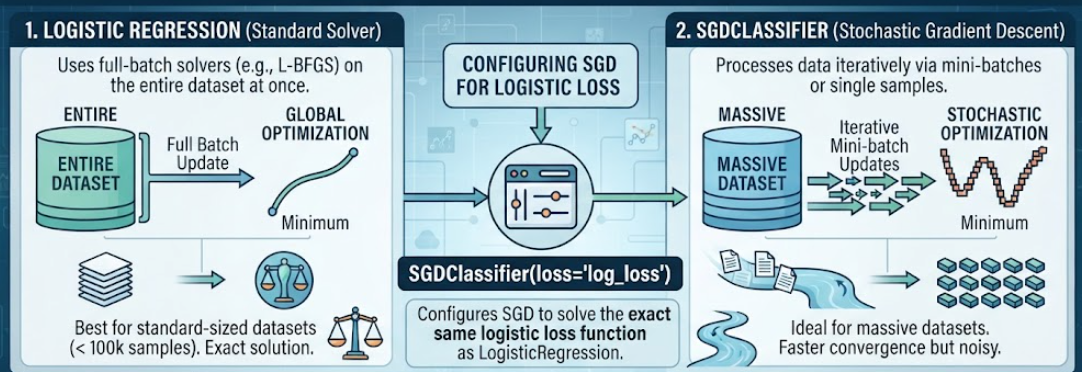

# **Softmax Regression (Multiclass Classification)**



* So far, we have looked at **binary classification** using Logistic Regression.

* However, real-world problems often involve more than two categories.

* **Softmax Regression (or Multinomial Logistic Regression**) is a generalization of logistic regression that handles multiple classes natively.

* Instead of outputting a single probability for a binary choice, the **softmax function** computes a probability distribution across all possible classes, ensuring that the sum of probabilities equals 1.

* In scikit-learn, this is handled automatically by setting **multi_class='multinomial'** in the **LogisticRegression** class.

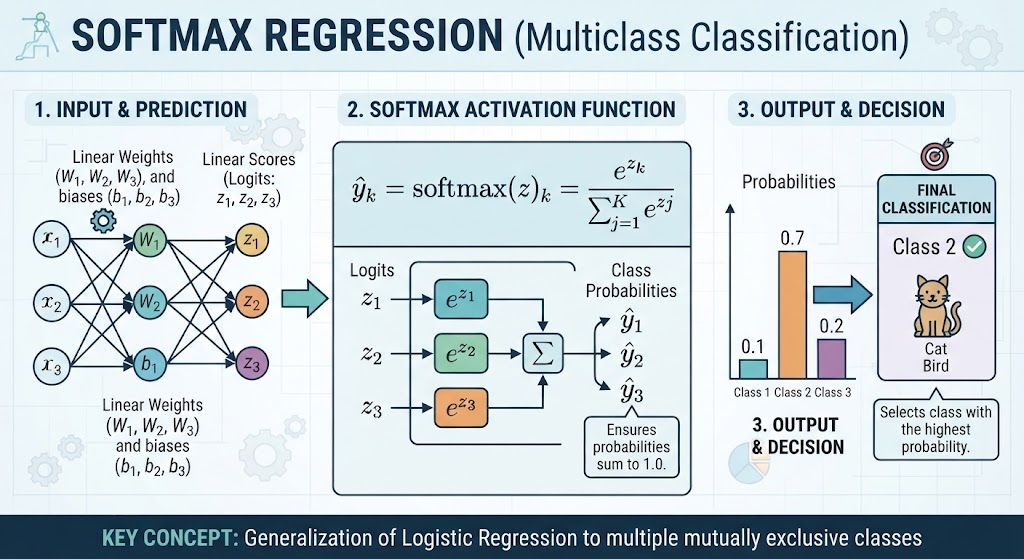

Softmax Regression Test Accuracy: 0.6562

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.55      0.52        11
           1       0.60      0.55      0.57        11
           2       0.90      0.90      0.90        10

    accuracy                           0.66        32
   macro avg       0.67      0.66      0.66        32
weighted avg       0.66      0.66      0.66        32



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


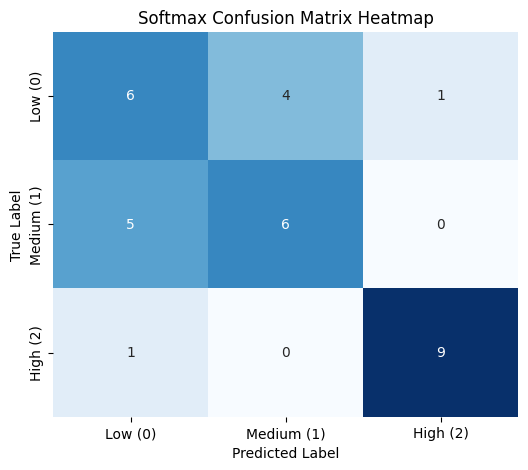

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the dataset
df = pd.read_csv('update_temperature.csv')

# Create a multi-class target variable for classification (3 bins: Low, Medium, High)
df['Temp_Category'] = pd.qcut(df['Avg_Temperature_degC'], q=3, labels=[0, 1, 2])
df['Temp_Category'] = df['Temp_Category'].astype(int)

# Define features and multi-class target
feature_cols = ['CO2_Emissions_tons_per_capita', 'Rainfall_mm', 'Renewable_Energy_pct', 'Forest_Area_pct']
X = df[feature_cols]
y = df['Temp_Category']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create Softmax Regression Pipeline (Multinomial Logistic Regression)
softmax_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42))
])

# Fit the pipeline to the training data
softmax_pipeline.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = softmax_pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Softmax Regression Test Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Softmax Confusion Matrix Heatmap')
plt.xticks(ticks=[0.5, 1.5, 2.5], labels=['Low (0)', 'Medium (1)', 'High (2)'])
plt.yticks(ticks=[0.5, 1.5, 2.5], labels=['Low (0)', 'Medium (1)', 'High (2)'])
plt.show()

# **Explanation of the Target Binning Code**


* The following lines transform **the continuous target variable(Avg_Temperature_degC)** into a **multi-class categorical target** with three **discrete categories (Low, Medium, High)** suitable for **softmax classification**.

```python
# Create a multi-class target variable for classification (3 bins: Low, Medium, High)
df['Temp_Category'] = pd.qcut(df['Avg_Temperature_degC'], q=3, labels=[0, 1, 2])
df['Temp_Category'] = df['Temp_Category'].astype(int)
```

* **The pd.qcut** function divides a continuous numerical column into equal-sized buckets (quantiles) based on the distribution of the data, rather than explicit numerical boundaries.

* Using **q=3** splits the temperature values into three bins so that each category contains approximately an equal number of samples (balanced binning).

* **labels=[0, 1, 2]** assigns integer categories to these bins, mapping the lowest temperatures to 0 (Low), middle temperatures to 1 (Medium), and highest temperatures to 2 (High).

* **pd.qcut** can sometimes return categorical data types or object arrays depending on pandas versions.

* Explicitly calling **.astype(int)** ensures that the class labels are cleanly converted into standard integer types, which is required by scikit-learn classification algorithms.

# **Evaluation of Softmax Regression Results**


* The results are mixed 00 while the model performs well on extreme values, it struggles significantly with intermediate categories.


* **The test accuracy is 0.66**, which is better than random guessing (about 33% for three classes), but noticeably lower than our binary logistic regression model (~90%).

* **High Temperature (Class 2)**: Excellent! Achieves a precision, recall, and F1-score of 0.90. The model easily separates high-temperature instances because they reside at the upper tail of the feature distribution.

* **Low Temperature (Class 0) & Medium Temperature (Class 1)**: Mediocre to Poor. F1-scores drop to 0.52 and 0.57, respectively, indicating a weak ability to separate these two groups.

* The heatmap reveals **heavy confusion between Low (0) and Medium (1)** classes. For instance, 5 actual medium-temperature instances were misclassified as low, and 4 low-temperature instances were misclassified as medium.

* Because we split the continuous target variable into three quantile bins (pd.qcut), the boundary values separating **"Low" and "Medium"** share very similar feature characteristics, making it hard for a linear decision boundary to cleanly divide them.

# **Summary of Training Models**


* In this exercise, we
  * moved from foundational linear regression to polynomial feature expansion
  * explored regularization strategies ($\alpha$ tuning for Ridge and Lasso)
  * transitioned into binary classification with Logistic Regression and ROC evaluation
  * compared optimization engines with SGDClassifier
  * extended our workflow to multi-class classification using Softmax Regression.


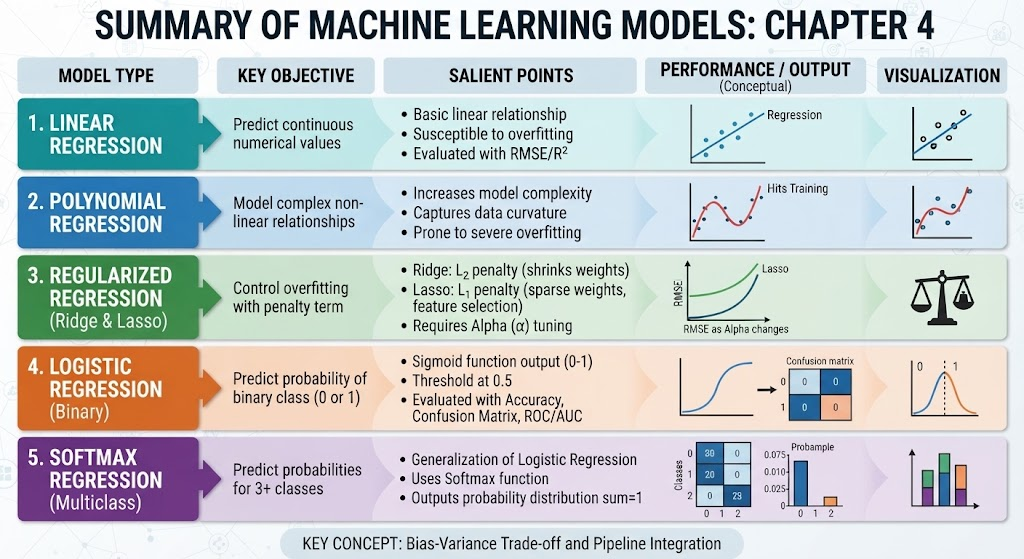